# Day 2 — Lecture 3: For Loops


## Goals for this lecture

- for-loops and combining loops with if statements
- Load and explore lidar wind data (copy-paste pandas block)
- Extract June 2020 hourly winds and format a matplotlib plot
- Seasonal daily-averaged wind capstone challenge


## Notebook and Learning Structure

Any text in black will be instruction and guidance and will usually start with a section number.<br>
<font color="#0F766E"> Any text in teal will be tasks to do and start with "Task".</font><br>
<font color="#B91C1C"> Any text in red will be optional challenges and advanced concepts for anyone looking to try more and say "Challenge".</font>


**Import Packages:**

In [1]:
# Path to shared bootcamp data (repo-root Datasets/)
DATA_FOLDER = "../../Datasets/"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


<h2> 2. Intro to for loops 

In [8]:
import numpy as np

# Make a numpy array of fruit names (an array of strings)
a=np.array(['apple','orange','pear','watermelon','grapes'])

# Loop through the array to see what it contains
for i in a:
    print('The value in this spot is '+str(i))

The value in this spot is apple
The value in this spot is orange
The value in this spot is pear
The value in this spot is watermelon
The value in this spot is grapes


When we work with data, we often want to loop through each index of an array as opposed to each value of an array. 
<br><br>Instead of writing:
<code> for i in a: </code>
<br> Where the i values are: apple, orange, pear, watermelon, grapes
<br>
<br>We write:
<code> for i in range(len(a)): </code>
<br> Then the i values are: 0,1,2,3,4 

**Note that the range() function starts counting from 0.*

In [9]:
# Make a numpy array of values
a=np.array(['apple','orange','pear','watermelon','grapes'])

# REMINDER: most functions that create lists/arrays in Python are non-inclusive. range() outputs an array
# with values from 0 to len(a), not including len(a).
for i in range(len(a)): 
    print('The value at index '+str(i)+' is '+str(a[i]))

The value at index 0 is apple
The value at index 1 is orange
The value at index 2 is pear
The value at index 3 is watermelon
The value at index 4 is grapes


In [10]:
# Print which fruit is stored at index 1
a[1]

'orange'

In [11]:
# Suppose we want to exclude the last element in the array when printing out the array values
# We can stop the count output by the range() function one index earlier

# Make a numpy array of values
a=np.array(['apple','orange','pear','watermelon','grapes'])

for i in range(len(a)-1): 
    print('The value at index '+str(i)+' is '+str(a[i]))

The value at index 0 is apple
The value at index 1 is orange
The value at index 2 is pear
The value at index 3 is watermelon


Notice how grapes, the last value in the array, was not printed.

<h2><font color="#0F766E"> Try to tackle the next two challenges over the next 5 minutes.


In [12]:
# Create an array
a=np.array([4,5,20,7,25,15,9,10])

<font color='#0F766E'> Using the code above, write a for loop that prints out the value multiplied by 2 for each value in the array


In [13]:
for i in a:
    print(i*2)

8
10
40
14
50
30
18
20


<font color='#B91C1C'> Write code that will print out the value in the array only if (*hint*) that value multiplied by 2 is 30. 


In [14]:
for i in a:
    if (i*2==30):
        print(i)

15


<h2>3. Let's look at some real data!


In [ ]:
from IPython.display import Image, display
display(Image("../figures/lidar_array_structure.png"))


The diagram above shows how a fancy tool called Lidar works to measure different things in Earth's atmosphere. You do not need to understand how this instrument works but we will be using data taken from this instrument in the code below.

In [15]:
# Uploading data-don't need to worry about how to write any of this code yet!
lidar_winds = pd.read_csv(DATA_FOLDER + "lidar_winds_short.csv")
lidar_winds['timestamp'] = pd.to_datetime(lidar_winds['timestamp'])

# Separate our year, month, day, time
lidar_winds['Year'] = pd.DatetimeIndex(lidar_winds['timestamp']).year
lidar_winds['Month'] = pd.DatetimeIndex(lidar_winds['timestamp']).month
lidar_winds['Day'] = pd.DatetimeIndex(lidar_winds['timestamp']).day
lidar_winds['Time'] = pd.DatetimeIndex(lidar_winds['timestamp']).time

# Create numpy arrays of values from dataarray
wind18m = np.asarray(lidar_winds['wspd18m'])
year = np.asarray(lidar_winds['Year'])
month = np.asarray(lidar_winds['Month'])
day = np.asarray(lidar_winds['Day'])
time = np.asarray(lidar_winds['Time'])


For every record in the lidar data we are working with, we have a time of the data record (stored in the timestamp array) and a windspeed for the data record (stored in the wind18m array). We've also extracted from the timestamp array the year, month, day, and time of each record. Let's investigate what this data looks like!

In [16]:
# Print the shape of the wind18m data
wind18m.shape

(84396,)

<font color='#0F766E'> What does this tell us about our wind18m array?


Our array contains 84,396 rows of data. 

In [17]:
# Print the first 4 values in wind18m 
print(wind18m[0:4])

# Notice how 'wind18m[0:4]' returns the values at indices 0, 1, 2, and 3 
# but NOT the value at index 4

[7.2923 7.8613 7.7594 7.4891]


<font color='#0F766E'> What does this tell us about our wind18m array?


This shows us the first 4 entries in our wind data.

In [18]:
# Print the first value of the year, month, day, and time arrays
print(year[0], month[0], day[0], time[0])

# Print the last value of the year, month, day, and time arrays
print(year[-1], month[-1], day[-1], time[-1])

2019 8 12 00:00:00
2021 3 21 23:50:00


<font color='#0F766E'> What does this tell us about our data?


This shows us the first and last times of the data entries. 

In [19]:
# Note: the functions np.nanmin() and np.nanmax(), perform the same operation as np.min() and np.max(), 
# except they do so while ignoring any empty entries in the data. These empty entries would be represented 
# with the value of NaN, which stands for "Not a Number".
print(np.nanmin(wind18m))
print(np.nanmax(wind18m))

0.5016
26.8913


<font color='#0F766E'> What does this tell us about our wind18m array?


Maximum and minimum wind speeds out of all of our data. 

<h2> Let's see how we can retrieve hourly wind data only from June 2020.

<h2><font color="#0F766E"> In the following code, after every # symbol, explain in your own words what the next line(s) of code are doing (take 20 minutes to do this).


In [20]:
# Let the variable num_times represent the number of times we have in our data 
num_times=len(wind18m)

# Initialize empty numpy arrays to store the date, time, and wind speed for days in June 2020
day_06_2020 = np.array([])
time_06_2020 = np.array([])
wind_06_2020 = np.array([])

# For a range of consecutive values from zero to the number of values in the wind array, do the following
for i in range(num_times):
    
    # Save the information we need for the next steps of the loop into variables
    year_i = year[i]
    month_i = month[i]
    day_i = day[i]
    time_i = time[i]
    wdsp = wind18m[i]
    
    # If the year is 2020 and the month is June, then do the following
    if year_i ==2020 and month_i == 6:
        # Add these values to our arrays for June
        day_06_2020 = np.append(day_06_2020,day_i)
        time_06_2020 = np.append(time_06_2020,time_i)
        wind_06_2020 = np.append(wind_06_2020,wdsp)

        
# Initialize new arrays to store the hourly-averaged wind speed and the day/hour corresponding
# to this average. The day/hour will act as our x while hourly-averaged wind speed acts as our
# y for a y vs x plot.
day_hour_06_2020 = np.array([])
hourly_wind_06_2020 = np.array([])

# Let this variable represent the number of times we have in our data from June 2020
num_times_06_2020 = len(wind_06_2020)
    
# For a range of consecutive values from zero to the total number of hourly timesteps in June 2020 
# (the number of 10 minutely timesteps divided by 6, since there are six 10-minute intervals in an hour)
for j in range(int(num_times_06_2020/6)):
    
    # Make a separate counter k, which counts through all of the 10-minutely June 2020 timesteps in each hour
    k=j*6
    
    # Make a new string day_hour that stores both the day and hour of the hour-averaged wind speed
    day_hour = str(day_06_2020[k]) + ' ' + str(time_06_2020[k])
    
    # Calculate the wind speed for this hour as the average wind speed across the the k, k+1, k+2,...,k+5 
    # timesteps of the 10 minute data
    hourly_wdsp = np.nanmean(wind_06_2020[k:k+6]) # note np.nanmean() is the same as np.mean() except it ignores missing data that is converted to "NaN" or "Not a Number"
    
    # Save the day/hour string constructed above and the average of wind speed found for the current hour
    # into our new arrays
    day_hour_06_2020 = np.append(day_hour_06_2020, day_hour)
    hourly_wind_06_2020 = np.append(hourly_wind_06_2020, hourly_wdsp)
    

<h2><font color="#0F766E"> Once you've finished explaining the above block of code, run the code to obtain hourly_wind_06_2020. Explain in words what the resulting array hourly_wind_06_2020 is. 


hourly_wind_06_2020 contains hour-averaged wind speeds for all hours in June 2020.

<font color="#B91C1C"> Plot wind_06_2020 with time on the x axis and 18m wind speed on the y axis.

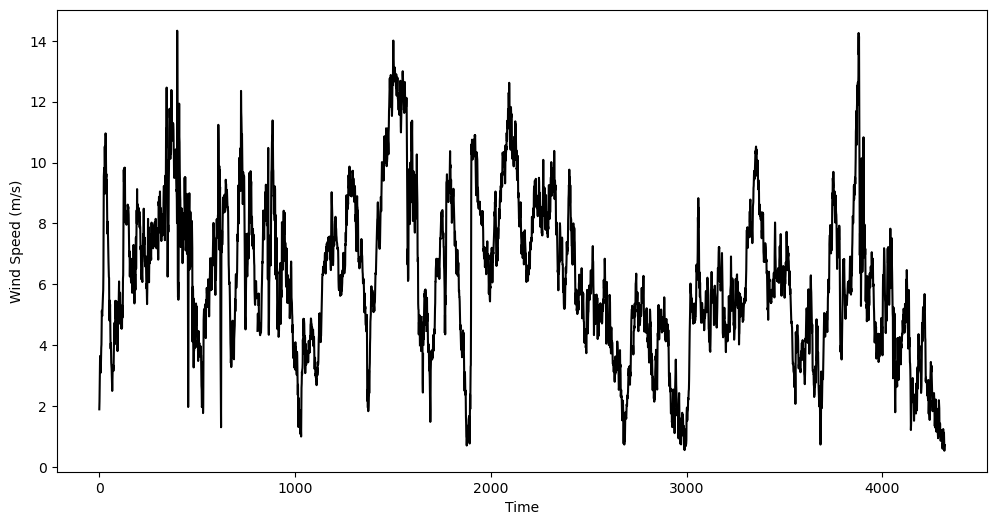

In [21]:
# Create the figure
fig=plt.figure(figsize=(12,6))

# Add one subplot to figure
ax = fig.add_subplot(1, 1, 1)

# Plot time on the x axis, wind on the y
plt.plot(wind_06_2020, color='black')

# Label axes
ax.set_xlabel('Time')
ax.set_ylabel('Wind Speed (m/s)')


plt.show()

<font color="#B91C1C"> Copy and paste the code above, then edit the loops to make them faster or use fewer lines.

In [22]:
# Let the variable num_times represent the number of times we have in our data 
num_times=len(wind18m)

# Initialize empty numpy arrays to store the date, time, and wind speed for days in June 2020
day_06_2020 = np.array([])
time_06_2020 = np.array([])
wind_06_2020 = np.array([])

# For a range of consecutive values from zero to the number of values in the wind array, do the following
for i in range(num_times):    
    # If the year is 2020 and the month is June, then do the following
    if year[i] ==2020 and month[i] == 6:
        # Add these values to our arrays for June
        day_06_2020 = np.append(day_06_2020,day[i])
        time_06_2020 = np.append(time_06_2020,time[i])
        wind_06_2020 = np.append(wind_06_2020,wind18m[i])

        
# Initialize new arrays to store the hourly-averaged wind speed and the day/hour corresponding
# to this average. The day/hour will act as our x while hourly-averaged wind speed acts as our
# y for a y vs x plot.
day_hour_06_2020 = np.array([])
hourly_wind_06_2020 = np.array([])

# Let this variable represent the number of times we have in our data from June 2020
num_times_06_2020 = len(wind_06_2020)
    
# For a range of consecutive values from zero to the total number of hourly timesteps in June 2020 
# (the number of 10 minutely timesteps divided by 6, since there are six 10-minute intervals in an hour)
for j in range(int(num_times_06_2020/6)):
    
    # Make a separate counter k, which counts through all of the 10-minutely June 2020 timesteps in each hour
    k=j*6
    
    # Make a new string day_hour that stores both the day and hour of the hour-averaged wind speed
    day_hour = str(day_06_2020[k]) + ' ' + str(time_06_2020[k])
    
    # Calculate the wind speed for this hour as the average wind speed across the the k, k+1, k+2,...,k+5 
    # timesteps of the 10 minute data
    hourly_wdsp = np.nanmean(wind_06_2020[k:k+6]) # note np.nanmean() is the same as np.mean() except it ignores missing data that is converted to "NaN" or "Not a Number"
    
    # Save the day/hour string constructed above and the average of wind speed found for the current hour
    # into our new arrays
    day_hour_06_2020 = np.append(day_hour_06_2020, day_hour)
    hourly_wind_06_2020 = np.append(hourly_wind_06_2020, hourly_wdsp)
    

<h2> 4. We can visualize our hourly wind data using Matplotlib to plot:

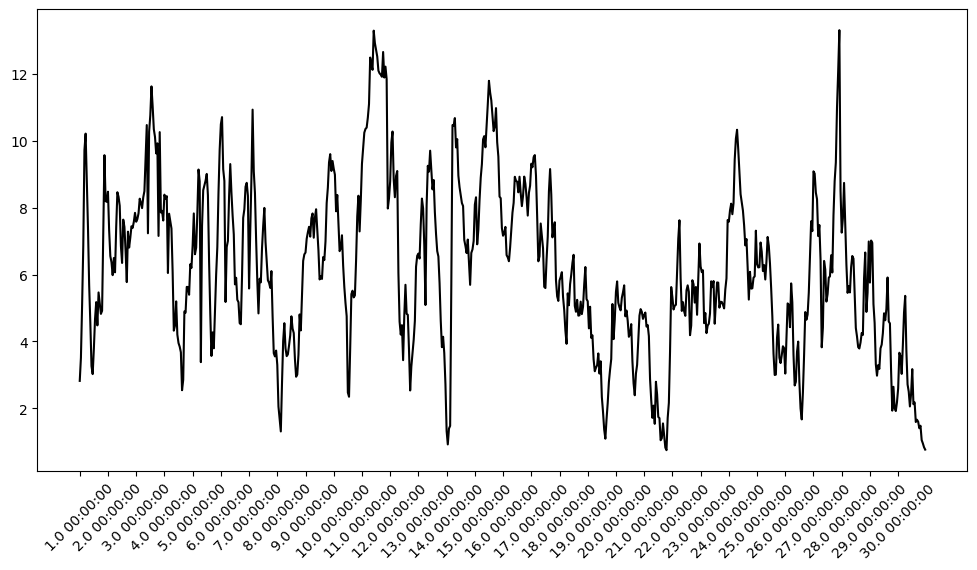

In [23]:
# Create the figure
fig=plt.figure(figsize=(12,6))

# Add one subplot to figure
ax= fig.add_subplot(1, 1, 1)

# Plot time on the x axis, wind on the y
plt.plot(day_hour_06_2020, hourly_wind_06_2020, color='black')

# Only label every 24 ticks (daily), otherwise it gets too crowded
ax.set_xticks(ax.get_xticks()[::24])

# Rotate tick labels for better spacing/viewing
ax.tick_params(axis='x', rotation=45)


plt.show()

<font color='#0F766E'> <h2> The code for the above image has been copied and pasted below. 


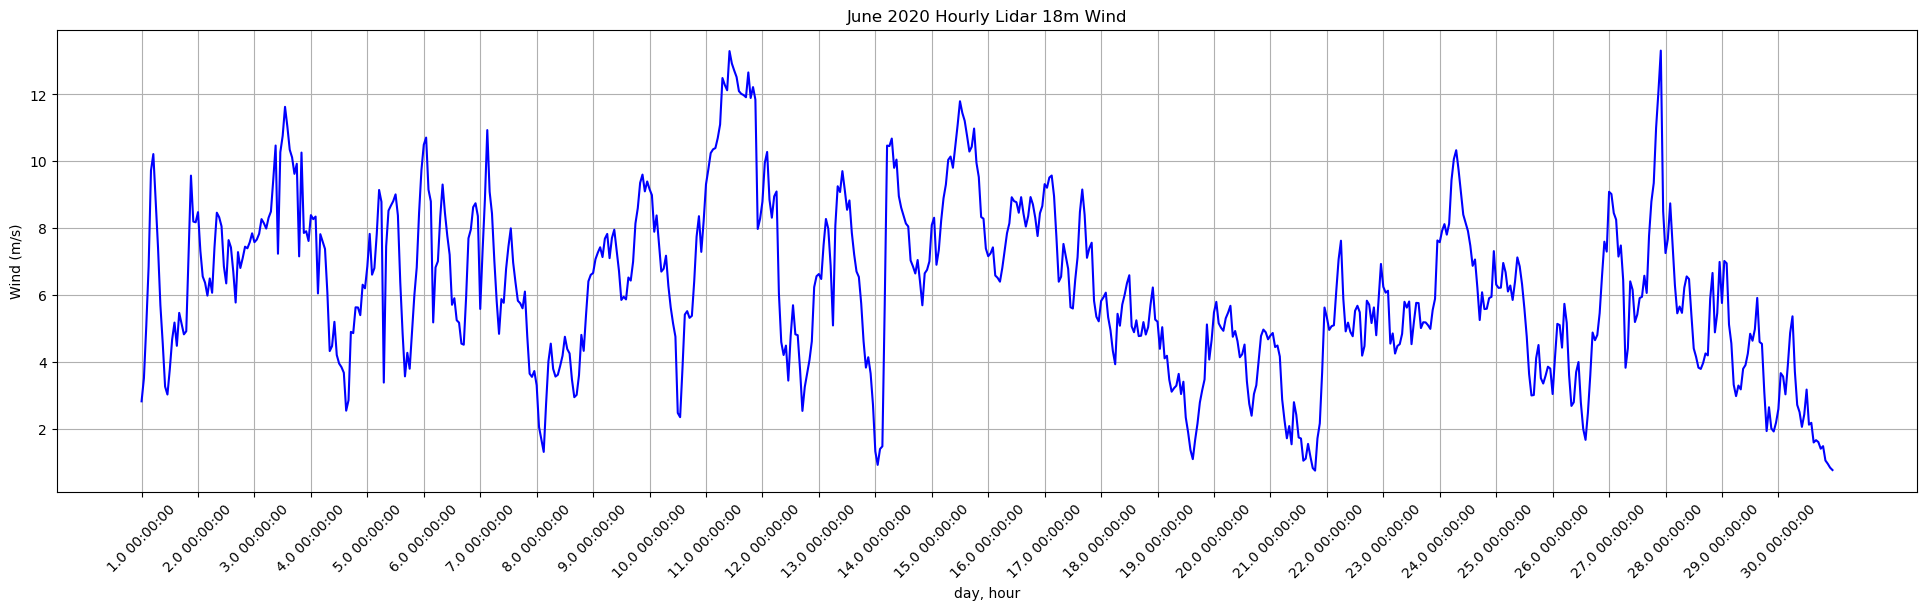

In [24]:
# Create the figure
fig=plt.figure(figsize=(24,6))  ## change the plot size

# Add one subplot to figure
ax= fig.add_subplot(1, 1, 1)

# Plot time on the x axis, wind on the y
plt.plot(day_hour_06_2020, hourly_wind_06_2020, color='blue')

# Only label every 24 ticks (daily), otherwise it gets too crowded
ax.set_xticks(ax.get_xticks()[::24])
# Rotate tick labels for better spacing/viewing
ax.tick_params(axis='x', rotation=45)

# Add a title
ax.set_title('June 2020 Hourly Lidar 18m Wind')

# Add x axis and y axis labels
ax.set_ylabel('Wind (m/s)')
ax.set_xlabel('day, hour')

# Add gridlines
ax.grid()

plt.show()

<font color='#0F766E'> <h2> Edit/add to the code above so that the output matches the image below it. 

- Hint: googling Matplotlib + whatever you want to do is a great tool for this challenge.
- You can also look at official documentation: https://matplotlib.org/
- Example/Hint: Googling "python add grid lines on matplotlib plot" leads to [a useful website](https://www.w3schools.com/python/matplotlib_grid.asp) 
    

<font color='#B91C1C'> <h2> Add a trend line or anything else you think may improve this graph!


In [ ]:
from IPython.display import Image, display
display(Image("../figures/wind_plot_reference.png"))
